In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from scipy.stats import uniform, norm, multivariate_normal
import seaborn as sns 
import multiprocessing as mp
from functools import partial
import time
import copy
import glob
import warnings
warnings.filterwarnings('ignore')

import pymc as pm
from main_pool import Main
from calibr_funcs import plot_results

from networks.model_output import SEIRModelOutput, SEIRParams
from networks.SEIR_network import SEIRNetworkModel

from hybrid_network_to_seir import NetworkSEIR_tuned,\
                                    generate_synthetic_data


import plot_funcs
import plot_hyb
import predict_Beta_I
import seir_discrete
import choice_start_day
%load_ext autoreload
%autoreload 2

pm.__version__  #'5.24.0'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'5.24.0'

In [2]:
# generate synthetic data with known parameters for testing
true_tau = 0.04
true_alpha = 0.8

days=range(1, 250)
data_p = 'new_network_check/'
'''
observed_data = generate_synthetic_data(alpha=true_alpha, lmbd=true_lmbd, 
                                        days=days, data_path=data_p,
                                       with_seirb=True, with_switch=False,
                                       for_observed=True)
'''
observed_data = pd.read_csv(f'results/{data_p}/observed.csv')

<Axes: >

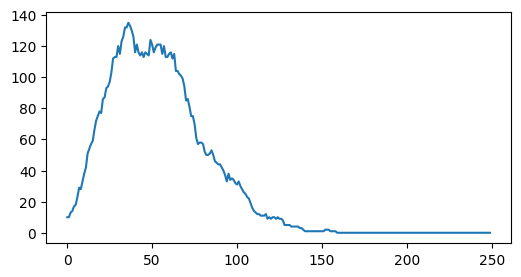

In [3]:
plt.subplots(figsize=(6,3))
observed_data.I.plot()

In [119]:
# create
network_params = {'n_nodes': 1000,
                  'network_type': 'ba'}
observed_prv = observed_data[['I']]
hn = NetworkSEIR_tuned(observed_prv, network_params,
                       fixed_sigma=0.1, fixed_gamma=0.08)

'''
true_tau = 0.04
true_alpha = 0.8
'''
# define parameter ranges for priors
prior_ranges = {"tau": (0.01, 1),  
                "alpha": (0.2, 1.) 
                }

start_time = time.time()
# run History Matching
hm_results = hn.history_matching(prior_ranges, n_samples=700,
                                 adaptive=True, accept_ratio=0.05,
                                 prepared=False)
end_time = time.time()

print('It took: ', end_time - start_time)

Network SEIR - Fixed parameters: sigma = 0.1, gamma = 0.08
Calibrating parameters: tau (transmission rate), rho (initial infection fraction)
Running Network SEIR history matching with 700 samples...


100%|██████████| 700/700 [00:41<00:00, 16.81it/s]

Accepted 35 parameter sets
It took:  41.678996324539185


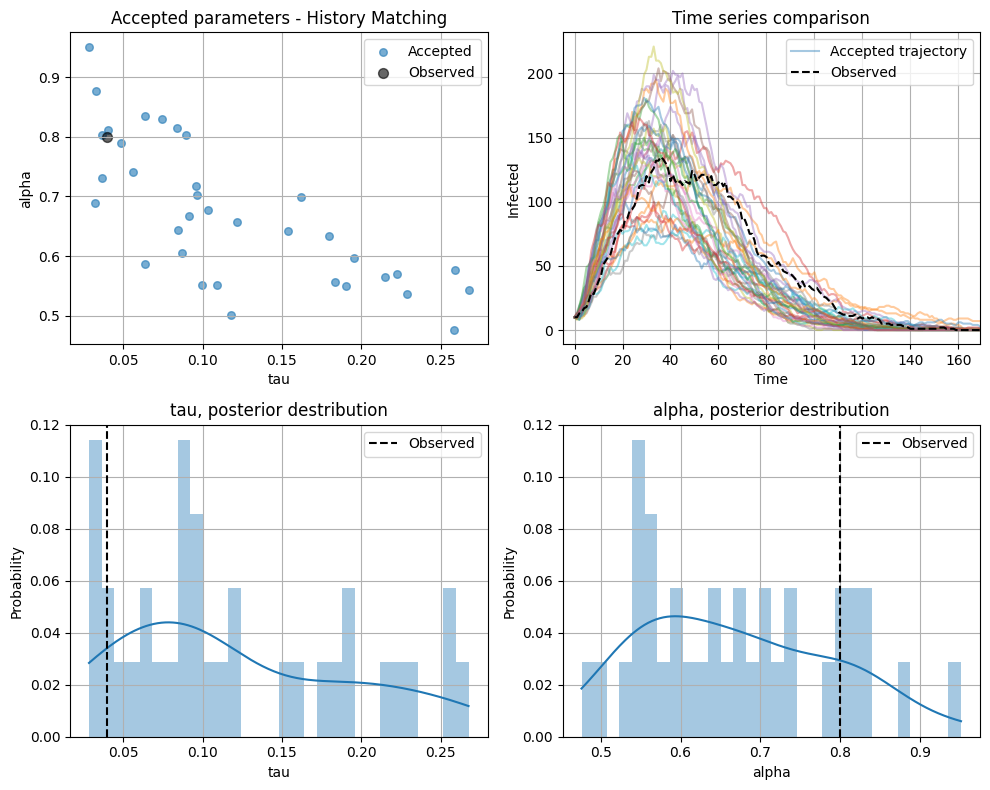

In [120]:
plot_results(observed_prv, hm_results, 
             "History Matching", n_trajectories=len(hm_results),
             true_p0=true_tau, true_p1=true_alpha)

In [121]:
def switch_seir(sim_data, gamma=0.1, delta=0.08,
                frac=0.01, modeling_duration=249, 
                method='expanding'):
    
    pop = sim_data.iloc[0,:4].sum()
    switches = sim_data[sim_data['I'] > pop*frac]
    
    if switches.shape[0]:
        switch_day = switches.index[0]
    else:
        switch_day = 7
        
    y0 = sim_data.iloc[switch_day,:4].values.flatten()
    # FOR FULL OBSERVED DATA
    ts = np.arange(modeling_duration-switch_day)
    if method=='expanding':
        beta = sim_data.iloc[:switch_day+1]['Beta'
                                ].expanding(1).mean().values[-1]
    elif method=='last':
        beta = sim_data.iloc[:switch_day+1]['Beta'].values[-1]
    elif method=='rolling':
        beta = sim_data.iloc[:switch_day+1]['Beta'
                                ].rolling(7).mean().values[-1]

    # Median from HM accepted parameters' trajectories!
    #median_b = pd.read_csv('median_beta.csv')
    #beta = median_b.iloc[switch_day:].values
    S,E,I,R = seir_discrete.seir_model(y0, ts, beta, 
                                       gamma, delta, stype='d', 
                                       beta_t=False).T

    fin = pd.DataFrame([S,E,I,R]).T
    fin.columns = ['S','E','I','R']

    fin['Beta'] = beta
    fin['day'] = ts+switch_day
    fin = pd.concat([sim_data.iloc[:switch_day], fin]
                   ).reset_index(drop=True)
    return fin

In [122]:
def simulation_func(rng, tau, alpha, modeling_duration, 
                    with_switch=False, num_runs=1, 
                    frac=0.01, size=None):
    
    tau = np.array(tau).flatten()[0]
    alpha = np.array(alpha).flatten()[0]
    
    modeling_duration = np.array(modeling_duration).flatten()[0] 
    
    method='expanding'
    network_type='ba'    
    gamma = 0.1
    delta=0.08
    n_nodes=1000
    
    chosen_seed = np.random.RandomState(42)
    network_model = SEIRNetworkModel(n_nodes, network_type, 
                                     chosen_seed)
    init_inf_frac = 0.01
    init_rec_frac = 1 - alpha

    all_results = []
    for run in range(np.array(num_runs).flatten()[0]):
        res = network_model.simulate(beta=tau, gamma=gamma, delta=delta, 
                                     init_inf_frac=init_inf_frac, 
                                     init_rec_frac=init_rec_frac,
                                     tmax=modeling_duration)

        seed_df = pd.DataFrame([res.S, res.E, res.I, res.R]).T
        seed_df.columns = ['S','E','I','R']
        seed_df['day'] = np.arange(seed_df.shape[0])
        # use "values", because "iloc" saves index info 
        # and messes with the calculation
        beta_calc = - seed_df.S.diff().values[1:] / (
                                seed_df.S.values[:-1] * seed_df.I.values[:-1]
                                )
        # the last Beta value cannot be calculated: no S_{t+1}
        seed_df['Beta'] = [*beta_calc, 0] 
        seed_df.fillna(0, inplace=True)
        
        if np.array(with_switch).flatten()[0]:
            if 'Beta' not in seed_df.columns:
                print(seed_df.columns)
            seed_df = switch_seir(seed_df, gamma=gamma, delta=delta,
                                  frac=np.array(frac).flatten()[0], 
                                  modeling_duration=modeling_duration, 
                                  method=method)

        all_results.append(seed_df)  

    if all_results:
        combined_results = pd.concat(all_results, 
                                     ignore_index=True)
        seed_df = combined_results.groupby('day').mean().reset_index()
        seed_df[['S','E','I','R']] = seed_df[['S','E','I','R']].round()

    return seed_df['I']
    

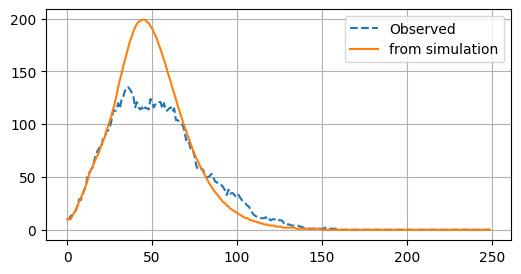

In [123]:
q = simulation_func(_, tau=[0.04], alpha=[0.8], modeling_duration=[250], 
                    with_switch=True, num_runs=10, 
                    frac=0.1, size=None)

plt.subplots(figsize=(6,3))
plt.plot(observed_data.I, ls='--', label='Observed')
plt.plot(q, label='from simulation')

plt.grid()
plt.legend()

In [124]:
hm_results['tau'].quantile(.1), hm_results['tau'].quantile(.9)

(np.float64(0.036489390827506865), np.float64(0.22627393192425543))

In [125]:
hm_results['alpha'].quantile(.1), hm_results['alpha'].quantile(.9)

(np.float64(0.5453681461261336), np.float64(0.8242004340114094))

In [126]:
draws = 60
chains = 3
progressbar = True

'''
true_tau = 0.04
true_alpha = 0.8
'''

with_switch=np.array(True) 
num_runs=5
frac=0.1
gamma = 0.1
delta=0.08
n_nodes=1000


with pm.Model() as pm_model:
    #alpha_v = pm.Uniform(name="alpha", lower=0.6, upper=0.8375)
    #lmbd_v = pm.Uniform(name="lmbd", lower=0.325, upper=0.5)
    
    p0_v = pm.Uniform(name="tau", 
                      lower=hm_results['tau'].quantile(.1), 
                      upper=hm_results['tau'].quantile(.9))
    p1_v = pm.Uniform(name="alpha", 
                      lower=hm_results['alpha'].quantile(.1), 
                      upper=hm_results['alpha'].quantile(.9))
    # вынесем, тк для прогноза нужно будет задавать размер
    modeling_duration = len(observed_data) #249
    

    sim = pm.Simulator("sim", simulation_func, 
                        params = (p0_v, p1_v, modeling_duration, 
                                  with_switch, num_runs, frac
                                 ),   
                       
                        epsilon=50, 
                        ndims_params=[1,1,1,1,1,1],
                        observed=observed_data['I'].values)
    
    # maybe parameter start == mean of HM ?
    #step=pm.DEMetropolisZ()
    
    start_time = time.time()
    idata = pm.sample_smc(#tune=tune, 
                          draws=draws, 
                          cores=6, chains=chains,
                          #step=step, 
                          progressbar=progressbar)
    end_time = time.time()
    
    idata.extend(pm.sample_posterior_predictive(idata,
                                            progressbar=progressbar))

print('It took ', end_time-start_time, 'sec')

Initializing SMC sampler...
Sampling 3 chains in 3 jobs


The number of samples is too small to check convergence reliably.
Sampling: [sim]


It took  342.4855420589447 sec


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.058,0.010,0.041,0.077,0.001,0.001,189.0,165.0,1.01
alpha,0.689,0.032,0.624,0.747,0.002,0.001,182.0,168.0,1.01


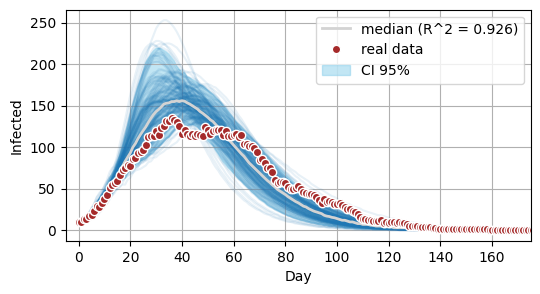

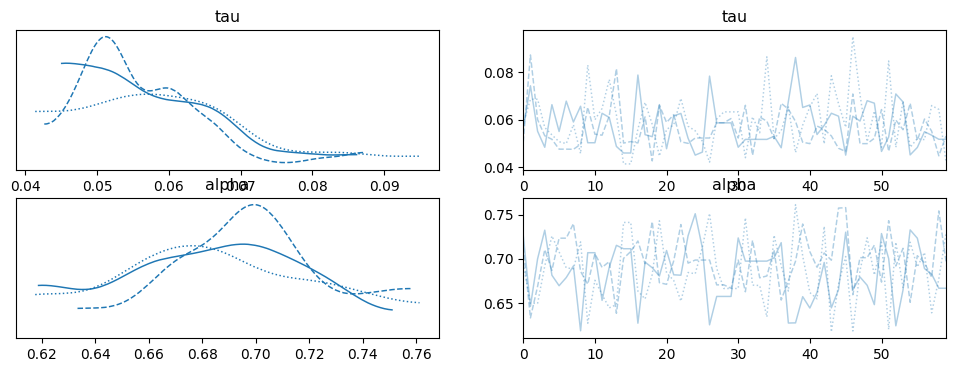

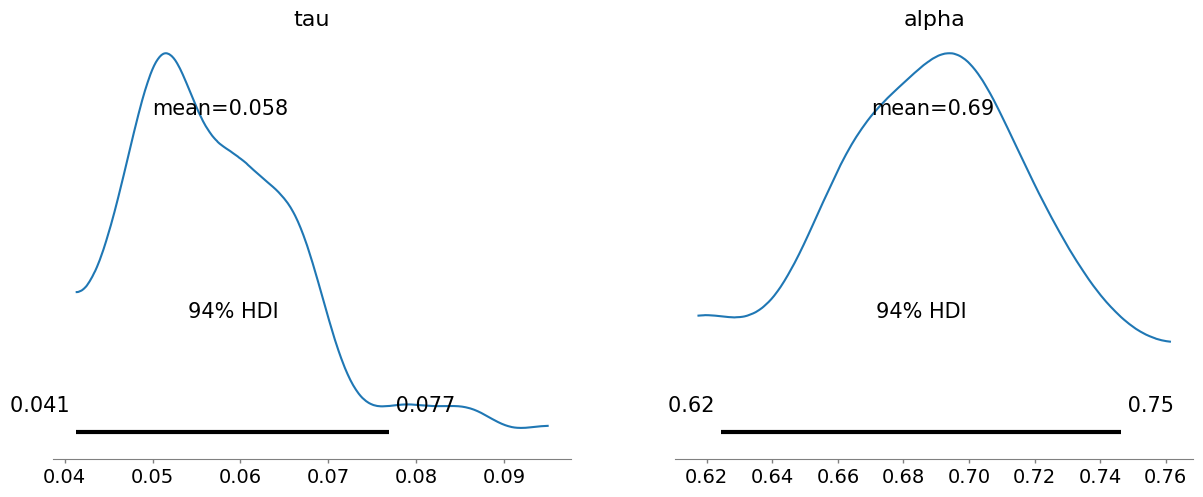

In [127]:
plot_funcs.plots(idata, observed_data['I'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.047,0.006,0.034,0.057,0.001,0.000,131.0,194.0,1.05
alpha,0.730,0.022,0.701,0.770,0.002,0.001,185.0,205.0,1.01


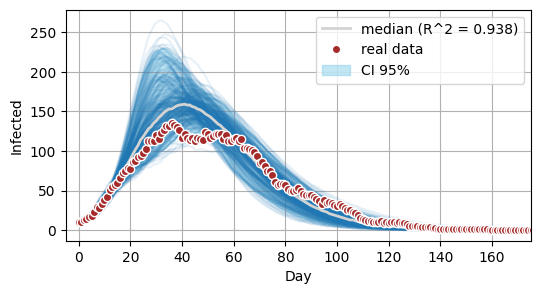

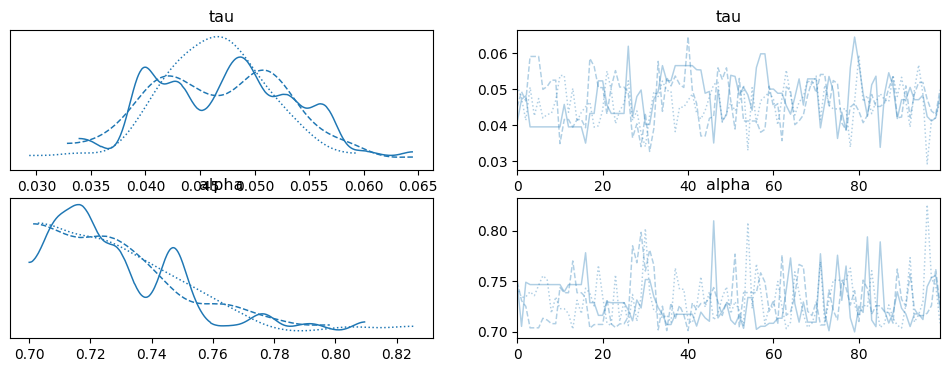

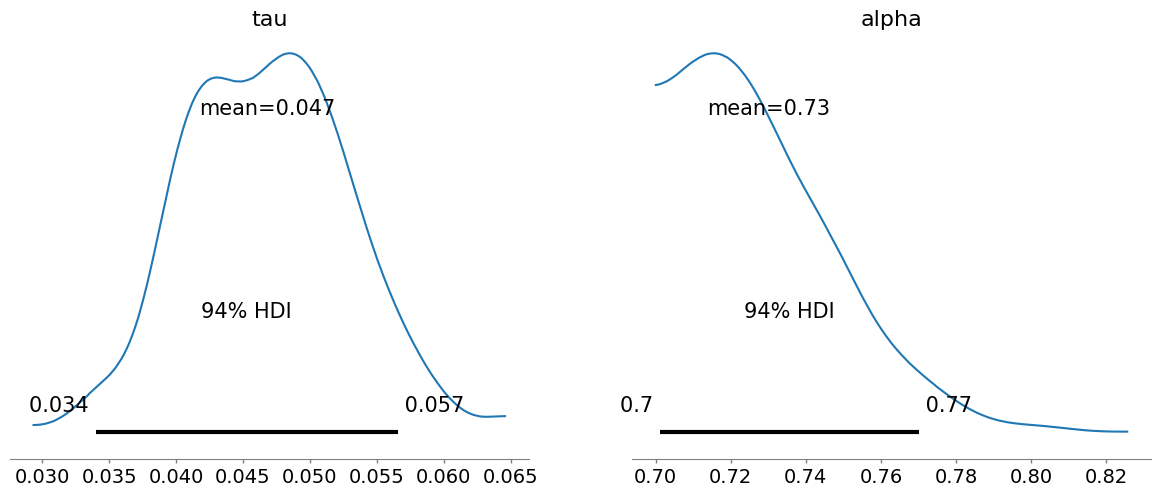

In [111]:
plot_funcs.plots(idata, observed_data['I'].values, '', 
                 simulation_func, for_pred=False, with_trace=True)
